In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf,sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, subcarrier_frequencies, RadioMapSolver
scene = load_scene(sionna.rt.scene.etoile)
# Configure arrays for all transmitters and receivers in the scene
# Add a transmitter and a receiver
scene.remove("tx")
scene.remove("rx")

scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="tr38901", polarization="V")
##############################################################################
# Replace the planar Rx array by a 1×64 ULA   (64 elements, 0.5 λ spacing)
##############################################################################
# N_ula = 64
# scene.rx_array = PlanarArray(num_rows=1,          # ONE row
#                              num_cols=N_ula,      # many columns
#                              vertical_spacing=0.5,  # ignored (only 1 row)
#                              horizontal_spacing=0.5, # 0.5 λ (default units = λ)
#                              pattern="tr38901",
#                              polarization="V")
scene.rx_array = PlanarArray(
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",  # or "iso"
    polarization="V")
# Tx can stay planar or point source; only Rx matters for AoA extraction

scene.add(Transmitter("tx", [-25,0.1,50]))
scene.add(Receiver("rx",    [ 25,0.1,50]))


# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene, max_depth=5,
                       los=True,
                       specular_reflection=True,
                       diffuse_reflection=False,
                       refraction=False,
                       synthetic_array=False
                       )

num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False, normalize_delays=False,
                   out_type='numpy')         # shape (1, 64, 1, 1, 1, 1024)

print("Shape of channel frequency response: ", h_freq.shape) 

In [ ]:
# -------------------------------------
#  Generate Three-Sector CSI Dataset
# -------------------------------------
import os, math, csv, random, numpy as np
import sionna, tensorflow as tf    
import matplotlib.pyplot as plt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, subcarrier_frequencies)

# ========== 0. 基本參數 =====================================================
OUT_DIR       = "dataset_test"          # 影像輸出資料夾
N_PER_SECTOR  = [5, 5, 5]            # 與論文相同樣本數
CARRIER_FREQ  = 3.5e9
BANDWIDTH     = 100e6
DELTA_F       = 30e3
N_SC          = int(BANDWIDTH/DELTA_F)          # 3333
SUBSAMPLE     = 4                               # 2-comb → 每 4 RE 取 1
FINAL_RE      = 408
SNR_DB_RANGE  = (23, 27)                        # 隨機 SNR ≈ 25±2 dB
TA_MAX_BIN    = 5                               # ±5*32ns

# ========== 1. 場景 & 天線 ===================================================
scene = load_scene(sionna.rt.scene.etoile)
scene.tx_array = PlanarArray(num_rows=4, num_cols=8,
                             horizontal_spacing=0.5,
                             vertical_spacing=2.0,
                             pattern="tr38901", polarization="cross")
scene.rx_array = PlanarArray(num_rows=4, num_cols=8,
                             horizontal_spacing=0.5, vertical_spacing=0.5,
                             pattern="tr38901", polarization="cross")
scene.remove("bs"); scene.remove("ue")
scene.add(Transmitter("bs", [100, 100, 30]))
scene.add(Receiver   ("ue", [0, 0, 30]))

freqs = subcarrier_frequencies(N_SC, DELTA_F)
p_solver = PathSolver()

# ========== 2. util: TA + AWGN =============================================
def add_ta_and_awgn(H, ta_max_bin=5, snr_db=25):
    """H:(2,32,408) numpy complex64"""
    C,Hant,W = H.shape
    # --- TA -------------------------------------------------
    k   = np.arange(W)
    dly = np.random.randint(-ta_max_bin, ta_max_bin+1)
    H   = H * np.exp(-1j*2*np.pi*dly*k/W)
    # --- AWGN ----------------------------------------------
    p_sig = np.mean(np.abs(H)**2)
    sigma = math.sqrt(p_sig / (10**(snr_db/10)))
    noise = sigma/np.sqrt(2) * (np.random.randn(*H.shape)+1j*np.random.randn(*H.shape))
    return H + noise

# ========== 3. 角-延遲轉換 ================================================
def to_angle_delay(csi):          # (32,408)  → (32,408)
    h_tau = np.fft.ifft(csi, axis=1, norm="ortho")
    return np.fft.fftshift(np.fft.fft(h_tau, axis=0), 0)

# ========== 4. 生成並保存 ===================================================
os.makedirs(OUT_DIR, exist_ok=True)
label_f = open(os.path.join(OUT_DIR, "labels.csv"), "w", newline="")
csv_w   = csv.writer(label_f)
csv_w.writerow(["file","sector","x","y","los"])

sector_center_deg = [0, 120, 240]
# ------------------------------------------------------------
# vis_had.py  --  put this in the same folder and import
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_had(H_ad_one_tx: np.ndarray,
             delta_f: float = 30e3,
             subsample: int = 4,
             elev: int = 30, azim: int = -60,
             save_path: str | None = None) -> None:
    """
    Visualise |H_ad| in 3-D surface & 2-D heat map.

    Parameters
    ----------
    H_ad_one_tx : np.ndarray
        Shape (N_ant, N_delay) complex64 after 2-D FFT.
    delta_f     : float
        Subcarrier spacing (Hz) *before* subsampling.
    subsample   : int
        Comb-factor. 4 means取1留3.
    elev,azim   : view angle for 3-D plot.
    save_path   : if given, saves PNG there.
    """
    # -------- axes ----------------------------------------------------------
    N_ant, N_tau = H_ad_one_tx.shape
    delay_res = 1 / (delta_f * subsample)          # seconds
    delay_us  = np.arange(N_tau) * delay_res * 1e6 # µs
    angle_deg = np.linspace(-90, 90, N_ant)        # simple ULA approx.

    # -------- magnitude in dB ----------------------------------------------
    mag_db = 20 * np.log10(np.abs(H_ad_one_tx) + 1e-9)

    # -------- 3-D surface ---------------------------------------------------
    Tau, Phi = np.meshgrid(delay_us, angle_deg)     # (N_ant,N_tau)
    fig = plt.figure(figsize=(10,4.5))
    ax  = fig.add_subplot(121, projection="3d")
    surf = ax.plot_surface(Tau, Phi, mag_db,
                           cmap="viridis", linewidth=0, antialiased=False)
    ax.set_xlabel("Delay (µs)"); ax.set_ylabel("AoA (°)"); ax.set_zlabel("|H| (dB)")
    ax.set_title("Angle–Delay Surface")
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, shrink=0.5, aspect=12)


    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"[INFO] Figure saved to {save_path}")
    else:
        plt.show()

for s, N in enumerate(N_PER_SECTOR):
    sec_dir = os.path.join(OUT_DIR, f"sector{s}")
    os.makedirs(sec_dir, exist_ok=True)
    center_deg = sector_center_deg[s]
    for idx in range(N):
        # ----- UE 隨機位置 (極座標) ---------------------------
        r   = random.uniform(5, 200)       # 5–200 m
        ang = math.radians(center_deg + random.uniform(-60, 60))
        x   = r*math.cos(ang)
        y   = r*math.sin(ang)
        print(f"sector {s} 位置: {x:.2f}, {y:.2f}")
        scene.get("ue").position = [x, y, 30]

        # ----- ray tracing ----------------------------------
        paths = p_solver(scene=scene, max_depth=4, los=True,
                         specular_reflection=True, diffuse_reflection=False,
                            refraction=False, synthetic_array=True)
       


       
        # ----- CSI pipeline ---------------------------------
        H = paths.cfr(freqs, normalize=False, normalize_delays=False,
                      out_type="numpy").squeeze()  
        print("H shape:", H.shape)
        

      
        H = H[..., ::SUBSAMPLE]                          
        mid = (H.shape[-1]-FINAL_RE)//2
        H = H[..., mid:mid+FINAL_RE]
        print("H shape:", H.shape)                     



        H_ad = H
        print("H_ad shape:", H_ad.shape) 
        plot_had(H_ad[0,:,:], delta_f=DELTA_F, subsample=SUBSAMPLE,
         elev=35, azim=-45, save_path=None) 
        
        mag   = np.abs(H_ad)
        phase = np.angle(H_ad)
        tensor = np.concatenate([mag, phase], axis=0).astype(np.float32) 

        # ----- save -----------------------------------------
        # f_name = f"{s}_{idx:05d}.npy"
        # np.save(os.path.join(sec_dir, f_name), tensor)
        # csv_w.writerow([f_name, s, f"{x:.2f}", f"{y:.2f}"])

        if (idx+1) % 1000 == 0 or idx == N-1:
            print(f"Sector {s} 生成 {idx+1}/{N}")

label_f.close()
print("Finished. 根目錄:", OUT_DIR)

In [ ]:
#!/usr/bin/env python3
# -------------------------------------
#  Generate Three-Sector CSI Dataset
#  Now with Angle-Delay images
# -------------------------------------
import os, math, csv, random, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sionna
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, subcarrier_frequencies)

# ---------- 1. 場景 & 天線 ---------------------------------------------
scene = load_scene(sionna.rt.scene.etoile)
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,
                             horizontal_spacing=0.5,
                             vertical_spacing=2.0,
                             pattern="tr38901", polarization="cross")
scene.rx_array = PlanarArray(num_rows=4, num_cols=8,
                             horizontal_spacing=0.5, vertical_spacing=0.5,
                             pattern="tr38901", polarization="cross")
scene.remove("bs"); scene.remove("ue")
scene.add(Transmitter("bs", [100, 100, 30]))
scene.add(Receiver   ("ue", [0, 0, 30]))

# ---------- 2. 頻率軸 & 路徑求解器 --------------------------------------
paths   = PathSolver()(scene=scene,max_depth=4, los=True,
                        specular_reflection=True, diffuse_reflection=False,
                        refraction=False, synthetic_array=True)

num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False, normalize_delays=False,
                   out_type='numpy')         # shape (1, 64, 1, 1, 1, 1024)

print("Shape h_freq: ", h_freq.shape)




In [ ]:
h = np.squeeze(h_freq)

# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(h, axes=1)

# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude');
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum");

In [ ]:
#!/usr/bin/env python3
# -------------------------------------
#  Generate Three-Sector CSI Dataset
#  Now with Angle-Delay images
# -------------------------------------
import os, math, csv, random, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sionna
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, subcarrier_frequencies)

# ---------- 1. 場景 & 天線 ---------------------------------------------
scene = load_scene(sionna.rt.scene.etoile)
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,
                             horizontal_spacing=0.5,
                             vertical_spacing=2.0,
                             pattern="tr38901", polarization="cross")
scene.rx_array = PlanarArray(num_rows=4, num_cols=8,
                             horizontal_spacing=0.5, vertical_spacing=0.5,
                             pattern="tr38901", polarization="cross")
scene.remove("bs"); scene.remove("ue")
scene.add(Transmitter("bs", [100, 100, 30]))
scene.add(Receiver   ("ue", [0, 0, 30]))

# ---------- 2. 頻率軸 & 路徑求解器 --------------------------------------
paths   = PathSolver()(scene=scene,max_depth=4, los=True,
                        specular_reflection=True, diffuse_reflection=False,
                        refraction=False, synthetic_array=True)

num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=True, out_type="numpy")

print("Shape of channel frequency response: ", h.shape)
### Compute the Delay-Doppler spectrum

# Squeeze useless dimensions
# [num_time_steps, fft_size]
h = h[0, 0, 0, 0, :, :] 

# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(h, axes=1)

# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude')
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum")

Delay   resolution (ns):  32
Doppler resolution (Hz):  29
Shape of h_full:  (1, 2, 1, 64, 1024, 1632)
h_ds shape before slice: (2, 64, 1024, 408)
h_ang_del shape: (2, 62, 408)
(2, 62, 408) (2, 62, 408) (4, 62, 408)
csi shape : (4, 62, 408)
real shape: (2, 62, 408)
imag shape: (2, 62, 408)


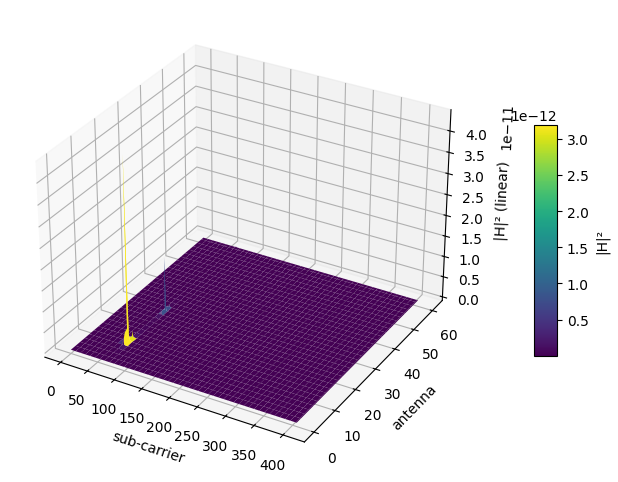

In [ ]:

# -------------------------------------
import os, math, csv, random, numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import matplotlib.pyplot as plt
import sionna
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, subcarrier_frequencies)

# ---------- 1. 場景 & 天線 ---------------------------------------------
scene = load_scene(sionna.rt.scene.etoile)
scene.frequency = 30e9 
scene.tx_array = PlanarArray(num_rows=4, num_cols=8,
                             horizontal_spacing=0.5, vertical_spacing=2.0,
                             pattern="tr38901", polarization="cross")

scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
                             horizontal_spacing=0.5, vertical_spacing=0.5,
                             pattern="tr38901", polarization="cross")
scene.remove("bs"); scene.remove("ue")
scene.add(Transmitter("bs", [10, 50, 80]))
scene.add(Receiver   ("ue", [-100, -100, 15]))

# ---------- 2. 頻率軸 & 路徑求解器 --------------------------------------
solver = PathSolver()
paths  = solver(scene=scene,max_depth=5, los=True,
                specular_reflection=True, diffuse_reflection=False,
                refraction=False, synthetic_array=True)


num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)


NUM_SC_TOTAL   = 1632       
SAMPLE_FACTOR  = 4             
NUM_SC         = NUM_SC_TOTAL // SAMPLE_FACTOR   
SC_SPACING     = 60e3 * SAMPLE_FACTOR           
NUM_SYM        = 1024                            

from sionna.rt import subcarrier_frequencies
h_full =[]
freqs = subcarrier_frequencies(NUM_SC_TOTAL, 60e3)  
h_full = paths.cfr(frequencies=freqs,
                   sampling_frequency=NUM_SYM*60e3,
                   num_time_steps=NUM_SYM,
                   normalize_delays=False, normalize=False,
                   out_type="tf")          
print("Shape of h_full: ", h_full.shape) 

h_full = tf.squeeze(h_full, axis=[0,2])    



h_ds = h_full[..., ::SAMPLE_FACTOR]                         

print("h_ds shape before slice:", h_ds.shape)  
h_t0   = h_ds[:, :62, 0, :]               


h_delay = tf.signal.ifft(h_t0)

h_angle_tmp = tf.transpose(h_delay, perm=[0,2,1])   
h_angle_tmp = tf.signal.fft(h_angle_tmp)
h_angle_tmp = tf.signal.fftshift(h_angle_tmp, axes=2)
h_ang_del   = tf.transpose(h_angle_tmp, perm=[0,2,1])
print("h_ang_del shape:", h_ang_del.shape)
  

real =[]
imag = []
csi  = []
real = tf.math.real(h_ang_del)
imag = tf.math.imag(h_ang_del)
csi  = tf.concat([real, imag], axis=0)   
print(real.shape, imag.shape, csi.shape)

print("csi shape :", csi.shape)                
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

real = tf.math.real(h_ang_del).numpy()  
imag = tf.math.imag(h_ang_del).numpy()  
print("real shape:", real.shape)
print("imag shape:", imag.shape)

r0 = real[1]; i0 = imag[1] 
power = np.abs(r0 + 1j*i0)**2

N_ant, N_subc = power.shape
X, Y = np.meshgrid(np.arange(N_subc), np.arange(N_ant))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, power, cmap='viridis')
ax.set_xlabel("sub-carrier")
ax.set_ylabel("antenna")
ax.set_zlabel("|H|² (linear)")
fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1, label='|H|²')
       
plt.show()





In [2]:
# Ray-tracing 真值


tau_gt = paths.tau.numpy().squeeze() * 1e9              # (RxPol, TxPort, Path)
phi_gt = np.degrees(paths.phi_t.numpy().squeeze())      # AoD → Tx 角度
print("Shape of τ_gt:", tau_gt.shape)
print("Shape of φ_Tx:", phi_gt.shape)   
# 取與你 slice 相同的 RxPol=1、TxPort[:62]
tau_pick = tau_gt.flatten()
phi_pick = phi_gt.flatten()

print("τ true  (ns):", np.sort(tau_pick)[:5], "...")
print("φ_Tx true(deg):", np.sort(phi_pick)[:5], "...")

# 找你圖上最大功率點的位置
peak_ang = np.argmax(power, axis=0)[0]   # angle bin
peak_dly = np.argmax(power, axis=1)[0]   # delay bin
print("peak bin  →  angle=", peak_ang, ", delay=", peak_dly,
      "≈", peak_dly*40.9, "ns")


Shape of τ_gt: (2,)
Shape of φ_Tx: (2,)
τ true  (ns): [302.51526 380.68707] ...
φ_Tx true(deg): [-108.434944 -108.43489 ] ...
peak bin  →  angle= 57 , delay= 30 ≈ 1227.0 ns


In [ ]:
scene.preview(paths=paths)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

Shape of h_full: (1, 2, 1, 64, 1, 1632)
Shape of h: (2, 64, 1632)
Final tensor shape: (2, 62, 408)


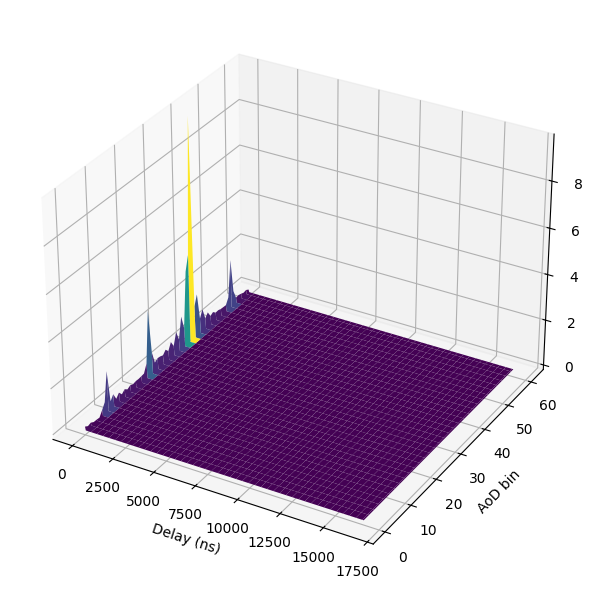

In [11]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Generate 2×62×408 CSI (Table-I) and plot AoD-Delay or AoA-Delay
----------------------------------------------------------------
Set the three flags below and run.  GPU 可以關掉也沒差。
"""
import sionna
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sionna.rt import (load_scene, PlanarArray, Transmitter,
                       Receiver, PathSolver, subcarrier_frequencies)

# ──── 可調參數 ─────────────────────────────────────────────────────────
USE_AOD = True          # True=AoD-Delay  False=AoA-Delay
USE_AOA = not USE_AOD   # 不想畫 AoA 就設 False
USE_3D  = True         # True=3-D surface；False=imshow

# ---------------------------------------------------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"      # CPU only

# ╭──  Table-I parameters  ────────────────────────────────────────────╮
CARRIER_F = 3.5e9
BANDWIDTH = 100e6         # 97.92 MHz ≈ 100 MHz
SC_SPACING = 60e3
RAW_SC     = 1632          # 97.92 MHz ≈ 100 MHz
DOWNSAMP   = 4
BS_ROWS, BS_COLS  = 4, 8
UE_RX_PORTS       = 2
KEEP_TX_PORTS     = 62                         # first 62 /64
# ╰────────────────────────────────────────────────────────────────────╯

scene = load_scene(sionna.rt.scene.etoile)
scene.frequency = CARRIER_F

# BS Tx 64 ports (cross-pol)

scene.tx_array = PlanarArray(num_rows=BS_ROWS, num_cols=BS_COLS,
                             horizontal_spacing=0.5, vertical_spacing=2.0,
                             pattern="tr38901", polarization="cross")

scene.rx_array = PlanarArray(num_rows=1, num_cols=UE_RX_PORTS,
                             horizontal_spacing=0.5, vertical_spacing=0.5,
                             pattern="tr38901", polarization="V")



scene.remove("bs"); scene.remove("ue")
scene.add(Transmitter("bs", [100., -100., 30.]))
scene.add(Receiver  ("ue", [ 200.,  300.,  15]))

solver = PathSolver()
paths  = solver(scene,
                max_depth=4, los=True,
                specular_reflection=True,
                synthetic_array=USE_AOD)   # AoD 需要 True；AoA 要 False

# ──── CFR ────────────────────────────────────────────────────────────
f_axis = subcarrier_frequencies(RAW_SC, SC_SPACING)
h_full = paths.cfr(
    frequencies=f_axis,
    sampling_frequency=SC_SPACING,
    num_time_steps=1,
    normalize=False,
    out_type="tf",
)                                   # (1, RxPort(2), 1, TxPort(?), 1, RAW_SC)
print("Shape of h_full:", h_full.shape)  # (1, 2, 1, 64, 1, 1632)
h = tf.squeeze(h_full, axis=[0,2,4])        # (RxPort, TxPort or 1, RAW_SC)
print("Shape of h:", h.shape)          # (2, 64, 3333)
# ↓↓↓ 共有的 Delay 軸轉換 ------------------------------------------------
h = h[:, :KEEP_TX_PORTS, ::DOWNSAMP]        # (2, 62, 408)
h_delay = tf.signal.ifft(tf.cast(h, tf.complex64))    # (2,62,408)

if USE_AOD:
    # IFFT 完 → FFT over TxPort
    h_sw = tf.transpose(h_delay, (0,2,1))             # (2,408,62)
    h_ang = tf.signal.fftshift(tf.signal.fft(h_sw), axes=-1)
    h_ang = tf.transpose(h_ang, (0,2,1))              # (2,62,408)
    angle_dim = 62; angle_label = "AoD bin"
else:
    # synthetic_array=False 時 RxPort 維度=2，TxPort=1
    h_sw = tf.transpose(h_delay, (1,2,0))             # (Tx=1,408,2)
    h_ang = tf.signal.fftshift(tf.signal.fft(h_sw), axes=-1)
    h_ang = tf.transpose(h_ang, (2,1,0))              # (2,408,1)
    angle_dim = 2; angle_label = "AoA bin"

print("Final tensor shape:", h_ang.shape)             # (2, angle, 408)

# ──── 取單一 Rx 天線 + 強度 ─────────────────────────────────────────────
amp = np.abs(h_ang.numpy()[0])                        # (angle, 408)

# build axes
delay_ns   = np.arange(408) * (1/(RAW_SC / DOWNSAMP * SC_SPACING))*1e9
angle_axis = np.arange(angle_dim)

# ──── Plot ───────────────────────────────────────────────────────────
if USE_3D:
    X, Y = np.meshgrid(delay_ns, angle_axis)
    fig  = plt.figure(figsize=(9,6))
    ax   = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, amp, cmap="viridis", linewidth=0)
    ax.set_xlabel("Delay (ns)")
    ax.set_ylabel(angle_label)
    ax.set_zlabel("|H| (linear)")
else:
    plt.figure(figsize=(7,5))
    plt.imshow(20*np.log10(amp+1e-12), origin="lower",
               extent=[delay_ns[0], delay_ns[-1], angle_axis[0], angle_axis[-1]],
               aspect="auto", cmap="viridis")
    plt.colorbar(label="|H| (dB)")
    plt.xlabel("Delay (ns)")
    plt.ylabel(angle_label)
    plt.title(f"{'AoD' if USE_AOD else 'AoA'}-Delay power map")
plt.tight_layout(); plt.show()


Shape of h_full (raw CFR): (1, 2, 1, 64, 1, 1632)
Shape of h_squeezed: (2, 64, 1632)
h_ds shape after subcarrier downsampling: (2, 64, 408)
h_t0 shape (spatial-frequency domain CSI): (2, 62, 408)
h_ang_del shape (angle-delay domain CSI): (2, 62, 408)
Real part shape: (2, 62, 408), Imaginary part shape: (2, 62, 408)
Final CSI for NN input (concatenated real/imag): (4, 62, 408)
Plotting power surface with 62 angle bins and 408 delay bins.


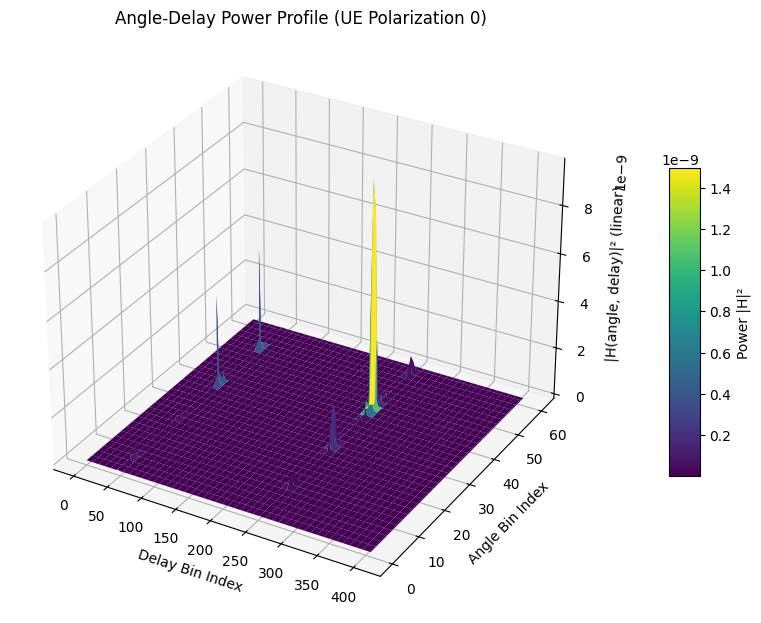

In [26]:
# -------------------------------------
import os, math, csv, random, numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Disable GPU usage if not needed or causing issues

import tensorflow as tf
import matplotlib.pyplot as plt
import sionna
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, subcarrier_frequencies, scene) # Added scene to imports for sionna.rt.scene.etoile

# ---------- 1. 場景 & 天線 (Scene & Antennas) ---------------------------------------------
# Load a predefined scene from Sionna
# The paper uses a custom setup, 'etoile' is a placeholder.
# For full reproduction, the scene geometry should match the paper's description.
current_scene = load_scene(sionna.rt.scene.etoile)

# Set carrier frequency according to the paper (3.5 GHz)
current_scene.frequency = 3.5e9 # Changed from 30e9

# Configure transmitter (BS) antenna array
# Paper: BS equipped with an 8-column antenna array, each column consists of 4 channels.
# Horizontal spacing dh = 0.5 lambda, vertical spacing dv = 2.0 lambda. Cross-polarization.
# This results in 4 rows, 8 columns, dual-polarized (2 ports per element) = 4*8*2 = 64 effective antennas/ports.
current_scene.tx_array = PlanarArray(num_rows=4,
                                     num_cols=8,
                                     horizontal_spacing=0.5, # In wavelengths
                                     vertical_spacing=2.0,   # In wavelengths
                                     pattern="tr38901",      # 3GPP antenna pattern
                                     polarization="cross")   # Enables dual polarization (V and H)

# Configure receiver (UE) antenna array
# Paper: UE antennas are 2 (implied from CSI dimensions 2x62x408)
# A 1x1 array with "cross" polarization provides 2 effective antenna ports.
current_scene.rx_array = PlanarArray(num_rows=1,
                                     num_cols=1,
                                     horizontal_spacing=0.5,
                                     vertical_spacing=0.5,
                                     pattern="tr38901",
                                     polarization="cross")

# Remove default BS and UE if they exist from the loaded scene
if "bs" in current_scene.objects:
    current_scene.remove("bs")
if "ue" in current_scene.objects:
    current_scene.remove("ue")

# Add Transmitter (BS) at the position specified in the paper (Table I: (100, -100, 30))
# Note: Sionna's coordinate system might need verification against the paper's assumptions.
current_scene.add(Transmitter("bs", [100., -100., 30.])) # Changed from [10, 50, 80]

# Add Receiver (UE) at a sample position.
# Paper: UEs distributed across three sectors at a height of 1.5 m.
# For a single UE plot, we use a placeholder position.
current_scene.add(Receiver("ue", [0., 0., 15])) # Changed Z-coordinate from 15 to 1.5

# ---------- 2. 頻率軸 & 路徑求解器 (Frequency Axis & Path Solver) --------------------------------------
# Configure ray tracing parameters
# Paper: Fibonacci method, 10,000 rays, max interaction count 4 (max_depth=5 if LoS is depth 1)
# Only direct and reflected paths considered.


solver = PathSolver() # Pass scene to solver constructor
paths = solver(scene=current_scene,max_depth=5, # Consistent with "interaction count 4"
               los=True,
               specular_reflection=True,
               diffuse_reflection=False, # Paper does not explicitly mention diffuse
               refraction=False,         # Paper does not explicitly mention refraction
               synthetic_array=True)     # Treats array as a single point for faster ray tracing

# OFDM parameters from the paper / typical values
# Paper: Subcarrier spacing 30 kHz. SRS adopts 2-comb structure -> 60 kHz between SRS REs.
# Bandwidth 100 MHz -> 1632 SRS REs.
# Down-sampling 4-to-1 -> 408 SRS REs, effective subcarrier spacing 240 kHz for these REs.
NUM_SC_TOTAL = 1632 # Total SRS REs over 100 MHz with 60kHz effective spacing
SAMPLE_FACTOR = 4   # Down-sampling factor
NUM_SC = NUM_SC_TOTAL // SAMPLE_FACTOR # Final number of subcarriers for CSI (408)
# Effective spacing between the 1632 SRS REs is 60kHz
SRS_RE_SPACING = 60e3
# The subcarrier spacing for the *final* 408 samples, after downsampling.
# This is also NUM_SC_TOTAL * SRS_RE_SPACING / NUM_SC, or SRS_RE_SPACING * SAMPLE_FACTOR
EFFECTIVE_SC_SPACING_AFTER_DS = SRS_RE_SPACING * SAMPLE_FACTOR # 240 kHz

# NUM_SYM is the number of OFDM symbols for time evolution if needed, or for Doppler calculation.
# The paper's target CSI (2x62x408) seems to be for a single time snapshot.
NUM_SYM = 1 # For a single snapshot CSI, as implied by final dimensions in paper.
            # If time evolution was needed, this would be > 1 (e.g., 1024 as in your original code)

# Frequencies for CFR calculation: NUM_SC_TOTAL points with SRS_RE_SPACING
freqs_for_cfr = subcarrier_frequencies(NUM_SC_TOTAL, SRS_RE_SPACING)

# Calculate Channel Frequency Response (CFR)
# sampling_frequency for time evolution: NUM_SYM * SRS_RE_SPACING (if NUM_SYM > 1)
# For NUM_SYM = 1, this parameter's impact on a single snapshot needs care.
# Let's use a nominal sampling frequency related to the OFDM structure.
# The paper mentions "num_time_steps=NUM_SYM" for paths.cfr.
# If NUM_SYM=1, it means we are taking the channel at one point in time.
h_full = paths.cfr(frequencies=freqs_for_cfr,
                   # A nominal sampling frequency for the time domain processing,
                   # if NUM_SYM > 1 this would be NUM_SYM * EFFECTIVE_SC_SPACING_AFTER_DS or similar.
                   # For NUM_SYM=1, its role is less direct for the snapshot.
                   # Let's use a value that would correspond to a typical OFDM symbol duration.
                   sampling_frequency=NUM_SYM * SRS_RE_SPACING, # Or NUM_SYM * some_ofdm_symbol_rate
                   num_time_steps=NUM_SYM,
                   normalize_delays=False,
                   normalize=False,
                   out_type="tf")

print(f"Shape of h_full (raw CFR): {h_full.shape}")
# Expected: [batch_size, num_rx_obj, num_rx_ant_ue, num_tx_obj, num_tx_ant_bs, num_time_steps, num_subcarriers_total]
# With 1 UE, 1 BS: [1, 1, 2 (UE_pol), 1, 64 (BS_pol), NUM_SYM, NUM_SC_TOTAL]
# -> [1, 1, 2, 1, 64, 1, 1632]
# Squeeze out batch_size, num_rx_obj, num_tx_obj dimensions
h_squeezed = h_full[0, :, 0, :, 0, :] # Squeeze out batch and object dimensions)
print(f"Shape of h_squeezed: {h_squeezed.shape}")
# Expected: [num_rx_ant_ue, num_tx_ant_bs, num_time_steps, num_subcarriers_total]
# -> [1,2, 64, 1, 1632]

# Down-sample in the subcarrier dimension
h_ds = h_squeezed[..., ::SAMPLE_FACTOR]
print(f"h_ds shape after subcarrier downsampling: {h_ds.shape}")
# Expected: [num_rx_ant_ue, num_tx_ant_bs, num_time_steps, NUM_SC (408)]
# -> [2, 64, 1, 408]

# Select the first (and only) time step (t=0) and 62 out of 64 BS antenna/polarization channels
# Paper's CSI dimension is (2 x 62 x 408)
h_t0 = h_ds[:, :62,  :] # Select 62 BS antennas from the 64 available
print(f"h_t0 shape (spatial-frequency domain CSI): {h_t0.shape}")
# Expected: [num_rx_ant_ue, 62 (selected_bs_ant), NUM_SC (408)]
# -> [2, 62, 408]

# Transform to Angle-Delay domain
# 1. IFFT along subcarrier dimension (frequency to delay)
h_delay = tf.signal.ifft(h_t0) # Axis -1 is default (subcarriers)
# Shape: [2, 62, 408_delays]

# 2. FFT along BS antenna dimension (spatial to angle)
# Transpose to bring BS antenna dimension to the last for FFT
h_angle_tmp = tf.transpose(h_delay, perm=[0, 2, 1]) # Shape: [2, 408_delays, 62_bs_ant]
h_angle_tmp = tf.signal.fft(h_angle_tmp) # FFT along the last dimension (BS antennas)
h_angle_tmp = tf.signal.fftshift(h_angle_tmp, axes=2) # Shift zero-frequency component to center for angle
# Transpose back
h_ang_del = tf.transpose(h_angle_tmp, perm=[0, 2, 1]) # Shape: [2, 62_angles, 408_delays]
print(f"h_ang_del shape (angle-delay domain CSI): {h_ang_del.shape}")

# Prepare CSI for neural network input (real and imaginary parts)
real_part = tf.math.real(h_ang_del)
imag_part = tf.math.imag(h_ang_del)
# Paper mentions "converting the complex CSI into its magnitude and phase components"
# or concatenating real/imag. Concatenation is common.
# csi_nn_input = tf.stack([real_part, imag_part], axis=0) # Example: (2, 2, 62, 408)
csi_nn_input = tf.concat([real_part, imag_part], axis=0) # Shape: (4, 62, 408) if concat along new axis 0
                                                       # Or (2, 2*62, 408) or (2, 62, 2*408) depending on model
print(f"Real part shape: {real_part.shape}, Imaginary part shape: {imag_part.shape}")
print(f"Final CSI for NN input (concatenated real/imag): {csi_nn_input.shape}")


# --- Plotting one UE's angle-delay CSI 3D surface ---
# Convert to NumPy for plotting
real_np = real_part.numpy()
imag_np = imag_part.numpy()

# Select one UE polarization for plotting (e.g., the first one, index 0)
# Your original code used index 1: r0 = real[1]; i0 = imag[1]
ue_pol_idx_to_plot = 0
r0 = real_np[ue_pol_idx_to_plot] # Shape: (62, 408)
i0 = imag_np[ue_pol_idx_to_plot] # Shape: (62, 408)

# Calculate power |H|^2
power = np.abs(r0 + 1j*i0)**2 # Shape: (62, 408)

N_angle_bins, N_delay_bins = power.shape
print(f"Plotting power surface with {N_angle_bins} angle bins and {N_delay_bins} delay bins.")

# Create meshgrid for plotting
X_delay, Y_angle = np.meshgrid(np.arange(N_delay_bins), np.arange(N_angle_bins))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_delay, Y_angle, power, cmap='viridis')

ax.set_xlabel("Delay Bin Index") # Updated label
ax.set_ylabel("Angle Bin Index") # Updated label
ax.set_zlabel("|H(angle, delay)|² (linear)")
ax.set_title(f"Angle-Delay Power Profile (UE Polarization {ue_pol_idx_to_plot})")

fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1, label='Power |H|²')
plt.show()

# --- To generate a dataset ---
# You would typically loop the following:
# 1. Set new UE positions: current_scene.receivers["ue"].position = [new_x, new_y, 1.5]
# 2. Re-run solver: paths = solver(...)
# 3. Re-calculate CFR and process to h_ang_del
# 4. Store h_ang_del (or its real/imag parts) and the UE coordinates.
# 5. Implement TA and AWGN as per the paper's description of practical imperfections.
#    - TA: Apply a phase shift in the frequency domain (h_t0) or a circular shift in the delay domain (h_delay).
#    - AWGN: Add complex Gaussian noise to h_t0 or h_ang_del.

In [27]:
current_scene.preview(paths=paths)  # Visualize the scene with paths

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …